# 02 · Classical machine-learning baselines

Hand-crafted features and classical classifiers, on exactly the splits the deep
models use. These baselines turn "why use a CNN?" into an empirical question
rather than received wisdom.

**Prerequisite:** `python training/train_classical.py`


In [1]:
# Make the project's own modules importable, and apply the OpenMP fix that must
# run before torch is imported.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "backend"))
sys.path.insert(0, str(PROJECT_ROOT / "training"))

import app.core.runtime  # noqa: F401  (sets OMP env before numpy/torch)

import json
import numpy as np
import matplotlib.pyplot as plt

from app.core.config import settings

print("Project root:", PROJECT_ROOT)


Project root: D:\Data science projects\Plant disease detection


## The feature vector

| Group | Dimensions | What it captures |
|---|---|---|
| RGB + HSV histograms | 192 | Colour distribution; chlorosis shifts green toward yellow |
| Colour moments | 18 | Mean, standard deviation, skew per channel |
| Local Binary Patterns | 26 | Micro-texture of lesions and mildew |
| GLCM (Haralick) | 48 | Coarse co-occurrence texture |
| HOG | 900 | Edge and gradient structure of lesion borders and veins |


In [2]:
from PIL import Image
from app.ml.datasets import read_manifest
from app.ml.features import extract_features, feature_group_slices

rows = read_manifest(settings.data_dir / "manifests" / "train_bench.csv")
with Image.open(rows[0].path) as img:
    vector = extract_features(img)

print("Feature vector:", vector.shape)
for group, span in feature_group_slices().items():
    print(f"  {group:<8} dims {span.start:>4} - {span.stop:<4} ({span.stop - span.start})")


Feature vector: (1184,)
  color    dims    0 - 210  (210)
  texture  dims  210 - 284  (74)
  hog      dims  284 - 1184 (900)


## How separable are the classes in feature space?

A 2-D PCA projection of the colour features gives a quick visual answer.

Cached feature matrix: (11400, 1184)


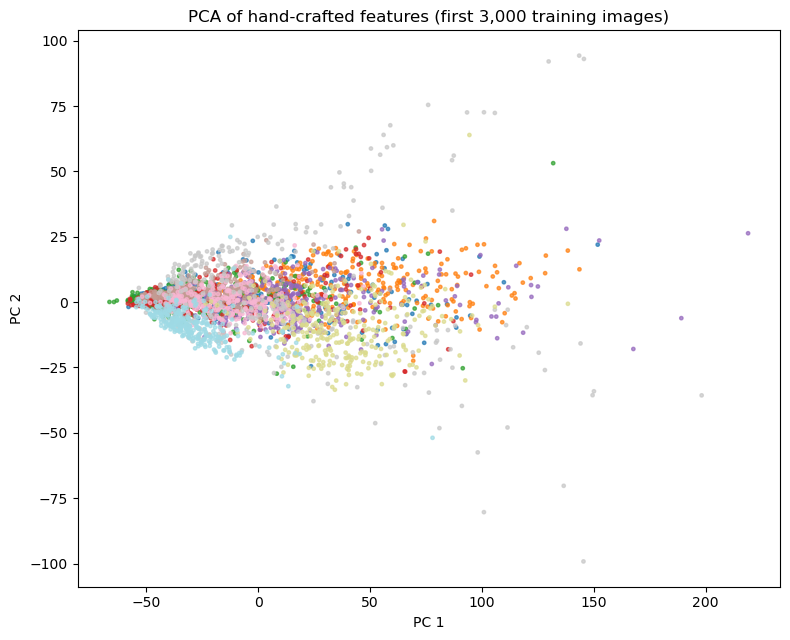

In [3]:
from sklearn.decomposition import PCA

cache = settings.artifacts_dir / "features" / "features_train_bench.npz"
if cache.exists():
    data = np.load(cache)
    X, y = data["X"], data["y"]
    print("Cached feature matrix:", X.shape)

    projected = PCA(n_components=2, random_state=0).fit_transform(X[:3000])
    fig, ax = plt.subplots(figsize=(8, 6.5))
    scatter = ax.scatter(projected[:, 0], projected[:, 1], c=y[:3000], cmap="tab20", s=6, alpha=0.7)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.set_title("PCA of hand-crafted features (first 3,000 training images)")
    plt.tight_layout(); plt.show()
else:
    print("Run `python training/train_classical.py` first to build the feature cache.")


## Results

All figures below come from the run, not from this notebook.

In [4]:
path = settings.results_dir / "classical_results.json"
if path.exists():
    results = json.loads(path.read_text(encoding="utf-8"))
    print(f"Train {results['train_samples']:,} / test {results['test_samples']:,} images, "
          f"{results['feature_dim']} features\n")
    print(f"{'MODEL':<44}{'ACC':>9}{'MACRO F1':>11}{'TOP-3':>9}{'FIT s':>9}")
    print("-" * 82)
    for entry in sorted(results["results"], key=lambda r: -r["metrics"]["accuracy"]):
        m = entry["metrics"]
        print(f"{entry['label']:<44}{m['accuracy']:>9.4f}{m['f1_macro']:>11.4f}"
              f"{m['top3_accuracy']:>9.4f}{entry['training_time_s']:>9.1f}")
else:
    print("Run `python training/train_classical.py` first.")


Train 11,400 / test 4,560 images, 1184 features

MODEL                                             ACC   MACRO F1    TOP-3    FIT s
----------------------------------------------------------------------------------
XGBoost (hand-crafted features)                0.9307     0.9302   0.9886    891.5
Random Forest (hand-crafted features)          0.9053     0.9037   0.9765     76.0
Linear SVM (hand-crafted features)             0.8796     0.8778   0.9601   4882.5
Logistic Regression (hand-crafted features)    0.8724     0.8719   0.9715     20.9


## Which feature group carries the signal?

Tree models expose feature importances, which can be summed per group.

In [5]:
if path.exists():
    for entry in results["results"]:
        importance = entry.get("feature_group_importance")
        if not importance:
            continue
        total = sum(importance.values()) or 1
        print(entry["label"])
        for group, value in sorted(importance.items(), key=lambda kv: -kv[1]):
            print(f"   {group:<8} {value / total * 100:5.1f}%")
        print()


Random Forest (hand-crafted features)
   color     45.0%
   hog       39.2%
   texture   15.8%

XGBoost (hand-crafted features)
   color     48.4%
   hog       37.3%
   texture   14.3%



## Reading these numbers

A classical baseline that reaches a high score does **not** make deep learning
pointless - it establishes the floor. If hand-crafted colour histograms reach
90%, a CNN reaching 96% bought six points, not ninety-six. Without the baseline
there is no way to separate "the model is good" from "the dataset is easy".
